# PCB Defect Dataset — Module 1: Data Preparation & Exploratory Data Analysis

**Dataset:** PCB Defect Detection (YOLO format)  
**Defect Classes:** mouse_bite, spur, missing_hole, short, open_circuit, spurious_copper  
**Course:** Data Mining Finals  

---
This notebook covers:
1. Understanding the business problem
2. Dataset inventory & split validation
3. Data cleaning (fixing class labels, missing images, duplicates)
4. Outlier detection on bounding box features
5. Exploratory Data Analysis & visualizations
6. Data leakage detection
7. Export `CleanedDataset.csv`

## 1. Business Problem

Printed Circuit Board (PCB) manufacturing has near-zero defect tolerance — a single short circuit or missing hole can cause device failure or safety hazards. Manual visual inspection is slow and error-prone at industrial scale.

**Goal:** Build a data pipeline to systematically clean, analyze, and understand a PCB defect image dataset so downstream detection models can be trained reliably.

**Target variable:** `class_name` — the type of defect present in each annotated bounding box.

**Why this is non-trivial for image data:**
- Labels live in separate `.txt` files (YOLO format) — mismatched parsing silently corrupts them
- Multiple defects can co-exist in one image
- Lighting conditions and rotations are built into the filename as metadata
- Class imbalance directly harms model precision per defect type

## 2. Setup

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

# ── Paths (run notebook from the notebooks/ directory) ─────────────────────
NOTEBOOK_DIR = Path('.')
DATA_ROOT    = (NOTEBOOK_DIR / '..' / 'data' / 'raw' / 'pcb-defect-dataset').resolve()
OUT_DIR      = (NOTEBOOK_DIR / '..' / 'data' / 'processed').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ['train', 'val', 'test']

# Correct class mapping — read from data.yaml, NEVER sort alphabetically.
# Alphabetical order gives {0:missing_hole, 1:mouse_bite, 2:open_circuit, ...} — WRONG.
CLASS_MAP = {
    0: 'mouse_bite',
    1: 'spur',
    2: 'missing_hole',
    3: 'short',
    4: 'open_circuit',
    5: 'spurious_copper'
}

print('DATA_ROOT exists:', DATA_ROOT.exists())
print('Class map:', CLASS_MAP)

DATA_ROOT exists: True
Class map: {0: 'mouse_bite', 1: 'spur', 2: 'missing_hole', 3: 'short', 4: 'open_circuit', 5: 'spurious_copper'}


## 3. Dataset Inventory

In [3]:
def strip_res(stem: str) -> str:
    """Remove trailing _256 or _600 resolution tag so labels and images can be matched."""
    return re.sub(r'_(256|600)$', '', stem)

inventory = {}
for split in SPLITS:
    img_dir = DATA_ROOT / split / 'images'
    lbl_dir = DATA_ROOT / split / 'labels'
    imgs = sorted(img_dir.glob('*.jpg'))
    lbls = sorted(lbl_dir.glob('*.txt'))
    img_keys = {strip_res(p.stem) for p in imgs}
    lbl_keys = {strip_res(p.stem) for p in lbls}
    inventory[split] = {
        'images': len(imgs),
        'labels': len(lbls),
        'img_no_label (by key)': len(img_keys - lbl_keys),
        'label_no_img (by key)': len(lbl_keys - img_keys),
    }

inv_df = pd.DataFrame(inventory).T
print(inv_df)
print(f"\nTotal images: {inv_df['images'].sum()}")
print("\nNote: 'light_' images use _256 label names but _600 image names — matched via base key.")

       images  labels  img_no_label (by key)  label_no_img (by key)
train    8534    8534                      0                      0
val      1066    1066                      0                      0
test     1068    1068                      0                      0

Total images: 10668

Note: 'light_' images use _256 label names but _600 image names — matched via base key.


## 4. Parse All Annotations into a Raw DataFrame

In [4]:
def parse_split(split: str) -> pd.DataFrame:
    img_dir = DATA_ROOT / split / 'images'
    lbl_dir = DATA_ROOT / split / 'labels'

    # Build a lookup: base_key (no resolution suffix) → actual image path
    # This handles the dataset quirk where light_* labels end in _256
    # but the corresponding images end in _600.
    img_lookup = {strip_res(p.stem): p for p in img_dir.glob('*.jpg')}

    records = []
    for lbl_path in sorted(lbl_dir.glob('*.txt')):
        key      = strip_res(lbl_path.stem)
        img_path = img_lookup.get(key)
        if img_path is None:
            continue
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cid = int(parts[0])
                xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                records.append({
                    'image_name': img_path.name,
                    'image_path': str(img_path),
                    'split': split,
                    'class_id': cid,
                    'class_name': CLASS_MAP.get(cid, f'unknown_{cid}'),
                    'x_center': xc,
                    'y_center': yc,
                    'bbox_width': bw,
                    'bbox_height': bh,
                    'bbox_area': round(bw * bh, 8),
                })
    return pd.DataFrame(records)

raw_df = pd.concat([parse_split(s) for s in SPLITS], ignore_index=True)
print('Raw shape:', raw_df.shape)
print('Unique images per split:')
print(raw_df.groupby('split')['image_name'].nunique())
raw_df.head()

Raw shape: (21664, 10)
Unique images per split:
split
test     1068
train    8534
val      1066
Name: image_name, dtype: int64


,image_name,image_path,split,class_id,class_name,x_center,y_center,bbox_width,bbox_height,bbox_area
0,l_light_01_missing_hole_01_1_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.4350,0.7008,0.0700,0.0550,0.003850
1,l_light_01_missing_hole_01_2_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.6367,0.0508,0.0667,0.0617,0.004115
2,l_light_01_missing_hole_01_2_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.7575,0.5333,0.0717,0.0600,0.004302
3,l_light_01_missing_hole_02_1_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.5633,0.2783,0.0667,0.0667,0.004449
4,l_light_01_missing_hole_02_1_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.3208,0.8733,0.0383,0.0567,0.002172


## 5. Data Cleaning

### 5a. Verify Class Mapping
The most common mistake with YOLO datasets: using a sorted/alphabetical class list instead of the `data.yaml` index order. Alphabetical gives `{0:missing_hole, 1:mouse_bite, 2:open_circuit, ...}` which is completely wrong.

In [5]:
mapping_check = raw_df.groupby(['class_id', 'class_name']).size().reset_index(name='bbox_count')
print('Class ID to Name mapping (must match data.yaml):')
print(mapping_check.to_string(index=False))

unknown = raw_df[raw_df['class_name'].str.startswith('unknown_')]
print(f'\nRows with unknown class_id: {len(unknown)}')

Class ID to Name mapping (must match data.yaml):
 class_id      class_name  bbox_count
        0      mouse_bite        3684
        1            spur        3636
        2    missing_hole        3612
        3           short        3508
        4    open_circuit        3548
        5 spurious_copper        3676

Rows with unknown class_id: 0


### 5b. Check for Missing Values

In [6]:
null_counts = raw_df.isnull().sum()
print('Null counts per column:')
print(null_counts)
print(f'\nRows with any null: {raw_df.isnull().any(axis=1).sum()}')

Null counts per column:
image_name     0
image_path     0
split          0
class_id       0
class_name     0
x_center       0
y_center       0
bbox_width     0
bbox_height    0
bbox_area      0
dtype: int64

Rows with any null: 0


### 5c. Check for Duplicate Annotation Rows

In [7]:
dup_cols = ['image_name', 'class_id', 'x_center', 'y_center', 'bbox_width', 'bbox_height']
dup_mask = raw_df.duplicated(subset=dup_cols)
print(f'Duplicate annotation rows: {dup_mask.sum()}')
if dup_mask.sum() > 0:
    raw_df = raw_df[~dup_mask].reset_index(drop=True)
    print(f'Shape after dedup: {raw_df.shape}')

Duplicate annotation rows: 0


### 5d. Validate Bounding Box Coordinate Ranges
YOLO coordinates are normalised to [0, 1]. Any value outside means a corrupted annotation.

In [8]:
coord_cols = ['x_center', 'y_center', 'bbox_width', 'bbox_height']
invalid = raw_df[(raw_df[coord_cols] < 0).any(axis=1) | (raw_df[coord_cols] > 1).any(axis=1)]
print(f'Annotations with coords outside [0,1]: {len(invalid)}')

for col in coord_cols:
    raw_df[col] = raw_df[col].clip(0.0, 1.0)
print('Coordinates clamped to [0, 1].')

Annotations with coords outside [0,1]: 0
Coordinates clamped to [0, 1].


### 5e. Image-Label Pairing Integrity

In [9]:
for split in SPLITS:
    img_dir  = DATA_ROOT / split / 'images'
    lbl_dir  = DATA_ROOT / split / 'labels'
    img_keys = {strip_res(p.stem) for p in img_dir.glob('*.jpg')}
    lbl_keys = {strip_res(p.stem) for p in lbl_dir.glob('*.txt')}
    no_label = img_keys - lbl_keys
    no_image = lbl_keys - img_keys
    print(f'{split:5s} | images without label: {len(no_label):4d} | labels without image: {len(no_image):4d}')
    
print('\nNote: matching is done by base key (resolution suffix stripped), so the')
print('_256-label / _600-image mismatch in the light_* files is handled correctly.')

train | images without label:    0 | labels without image:    0
val   | images without label:    0 | labels without image:    0
test  | images without label:    0 | labels without image:    0

Note: matching is done by base key (resolution suffix stripped), so the
_256-label / _600-image mismatch in the light_* files is handled correctly.


### 5f. Empty Label Files (background-only images)

In [10]:
any_empty = False
for split in SPLITS:
    lbl_dir = DATA_ROOT / split / 'labels'
    empty = [p.name for p in lbl_dir.glob('*.txt') if p.stat().st_size == 0]
    if empty:
        print(f'{split}: {len(empty)} empty label files (background/unlabelled images)')
        any_empty = True

if not any_empty:
    print('No empty label files — every image has at least one annotation.')

No empty label files — every image has at least one annotation.


### 5g. Enrich with Filename-Encoded Metadata

In [11]:
def parse_filename_meta(filename: str) -> dict:
    name = filename.replace('.jpg', '')
    if name.startswith('rotation_270'):
        aug = 'rotation_270'
    elif name.startswith('rotation_90'):
        aug = 'rotation_90'
    elif name.startswith('l_'):
        aug = 'lateral'
    else:
        aug = 'original'
    if name.endswith('_256'):
        res = 256
    elif name.endswith('_600'):
        res = 600
    else:
        m = re.search(r'_(\d+)$', name)
        res = int(m.group(1)) if m else -1
    m = re.search(r'light_(\d+)', name)
    lighting = int(m.group(1)) if m else -1
    return {'augmentation': aug, 'resolution': res, 'lighting_id': lighting}

unique_imgs = raw_df[['image_name']].drop_duplicates()
meta_rows   = unique_imgs['image_name'].apply(lambda n: pd.Series(parse_filename_meta(n)))
meta_rows.index = unique_imgs.index
unique_imgs = pd.concat([unique_imgs.reset_index(drop=True), meta_rows.reset_index(drop=True)], axis=1)

raw_df = raw_df.merge(unique_imgs, on='image_name', how='left')

print('Augmentation distribution per split:')
print(raw_df.groupby(['split','augmentation'])['image_name'].nunique().unstack(fill_value=0))

Augmentation distribution per split:
augmentation  lateral  original  rotation_270  rotation_90
split                                                     
test              281       239           277          271
train            2106      2164          2117         2147
val               280       264           273          249


### 5h. Add Pixel-Space BBox Dimensions and Aspect Ratio

In [12]:
raw_df['img_size_px']    = raw_df['resolution'].replace(-1, np.nan)
raw_df['bbox_width_px']  = raw_df['bbox_width']  * raw_df['img_size_px']
raw_df['bbox_height_px'] = raw_df['bbox_height'] * raw_df['img_size_px']
raw_df['bbox_area_px']   = raw_df['bbox_width_px'] * raw_df['bbox_height_px']
raw_df['aspect_ratio']   = raw_df['bbox_width'] / raw_df['bbox_height'].replace(0, np.nan)

raw_df[['bbox_width_px','bbox_height_px','bbox_area_px','aspect_ratio']].describe().round(2)

,bbox_width_px,bbox_height_px,bbox_area_px,aspect_ratio
count,21664.00,21664.00,21664.00,21664.00
mean,30.31,30.30,939.64,1.13
std,12.12,12.15,631.88,0.62
min,9.00,7.98,131.76,0.09
25%,21.96,21.00,542.00,0.76
50%,27.96,27.96,779.22,1.00
75%,36.00,36.00,1158.48,1.32
max,118.02,118.98,8923.50,12.55


## 6. Outlier Detection on Bounding Box Features

In [13]:
outlier_cols = ['bbox_area', 'bbox_width', 'bbox_height', 'aspect_ratio']
outlier_summary = []

for col in outlier_cols:
    col_data = raw_df[col].dropna()
    z       = np.abs(stats.zscore(col_data))
    iqr     = col_data.quantile(0.75) - col_data.quantile(0.25)
    iqr_lo  = col_data.quantile(0.25) - 1.5 * iqr
    iqr_hi  = col_data.quantile(0.75) + 1.5 * iqr
    outlier_summary.append({
        'feature': col,
        'z_score_outliers (|z|>3)': (z > 3).sum(),
        'iqr_outliers': ((col_data < iqr_lo) | (col_data > iqr_hi)).sum(),
        'min': round(col_data.min(), 4),
        'max': round(col_data.max(), 4),
        'mean': round(col_data.mean(), 4),
        'std': round(col_data.std(), 4),
    })

pd.DataFrame(outlier_summary)

,feature,z_score_outliers (|z|>3),iqr_outliers,min,max,mean,std
0,bbox_area,362,956,0.0004,0.0248,0.0026,0.0018
1,bbox_width,297,748,0.0150,0.1967,0.0505,0.0202
2,bbox_height,318,683,0.0133,0.1983,0.0505,0.0203
3,aspect_ratio,302,1413,0.0875,12.5533,1.1310,0.6243


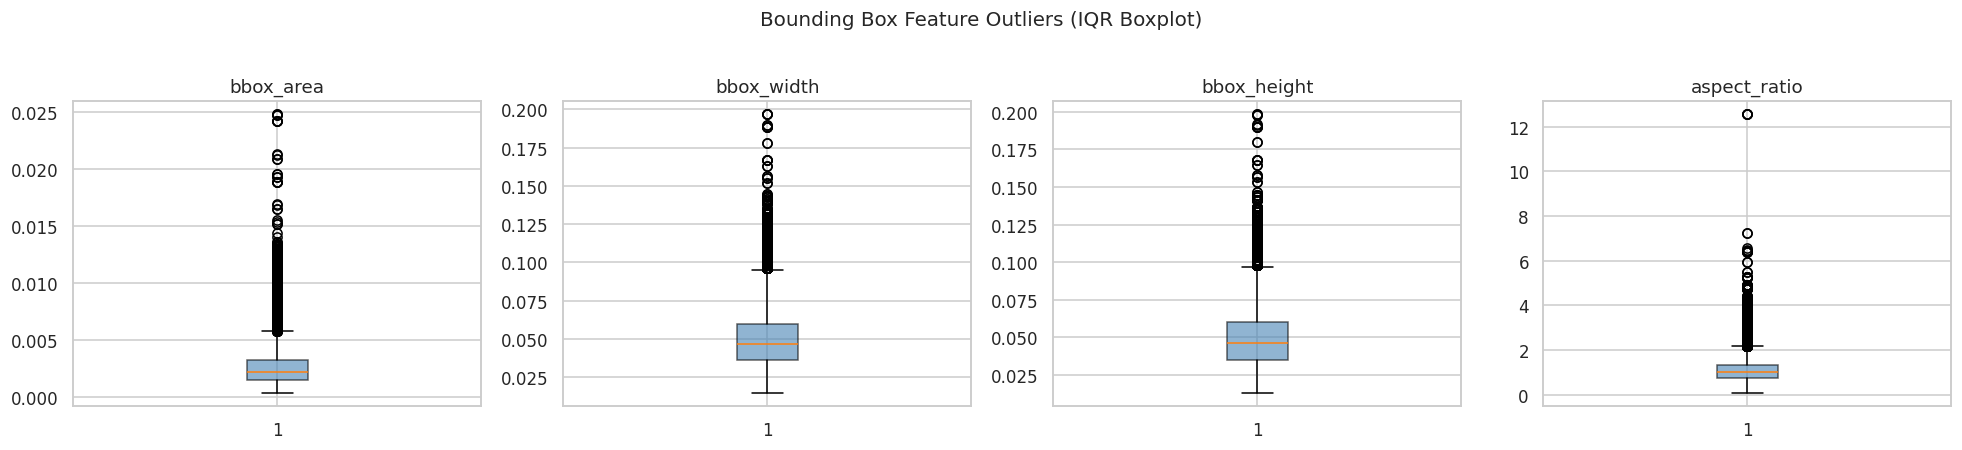

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(raw_df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
plt.suptitle('Bounding Box Feature Outliers (IQR Boxplot)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Flag outliers — keep them, they are real defect characteristics
for col, flag_col in [('bbox_area', 'is_outlier_area'), ('aspect_ratio', 'is_outlier_ar')]:
    p01 = raw_df[col].quantile(0.01)
    p99 = raw_df[col].quantile(0.99)
    raw_df[flag_col] = (raw_df[col] < p01) | (raw_df[col] > p99)

print(f'BBox area extreme outliers (top/bottom 1%): {raw_df["is_outlier_area"].sum()}')
print(f'Aspect ratio extreme outliers (top/bottom 1%): {raw_df["is_outlier_ar"].sum()}')
print('Outliers are flagged but NOT removed — unusual sizes can be genuine defects.')

BBox area extreme outliers (top/bottom 1%): 430
Aspect ratio extreme outliers (top/bottom 1%): 432
Outliers are flagged but NOT removed — unusual sizes can be genuine defects.


## 7. Save CleanedDataset.csv

In [16]:
keep_cols = [
    'image_name', 'image_path', 'split',
    'class_id', 'class_name',
    'x_center', 'y_center', 'bbox_width', 'bbox_height', 'bbox_area',
    'bbox_width_px', 'bbox_height_px', 'bbox_area_px', 'aspect_ratio',
    'augmentation', 'resolution', 'lighting_id',
    'is_outlier_area', 'is_outlier_ar',
]
cleaned_df = raw_df[keep_cols].copy()

out_path = OUT_DIR / 'CleanedDataset.csv'
cleaned_df.to_csv(out_path, index=False)

print(f'Saved to: {out_path}')
print(f'Shape: {cleaned_df.shape}')
cleaned_df.head()

Saved to: /home/codrei/my_first_ml_project/DATA MINING/FINALS/pcb-defect-mining/data/processed/CleanedDataset.csv
Shape: (21664, 19)


,image_name,image_path,split,class_id,class_name,x_center,y_center,bbox_width,bbox_height,bbox_area,bbox_width_px,bbox_height_px,bbox_area_px,aspect_ratio,augmentation,resolution,lighting_id,is_outlier_area,is_outlier_ar
0,l_light_01_missing_hole_01_1_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.4350,0.7008,0.0700,0.0550,0.003850,42.00,33.00,1386.0000,1.272727,lateral,600,1,False,False
1,l_light_01_missing_hole_01_2_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.6367,0.0508,0.0667,0.0617,0.004115,40.02,37.02,1481.5404,1.081037,lateral,600,1,False,False
2,l_light_01_missing_hole_01_2_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.7575,0.5333,0.0717,0.0600,0.004302,43.02,36.00,1548.7200,1.195000,lateral,600,1,False,False
3,l_light_01_missing_hole_02_1_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.5633,0.2783,0.0667,0.0667,0.004449,40.02,40.02,1601.6004,1.000000,lateral,600,1,False,False
4,l_light_01_missing_hole_02_1_600.jpg,/home/codrei/my_first_ml_project/DATA MINING/F...,train,2,missing_hole,0.3208,0.8733,0.0383,0.0567,0.002172,22.98,34.02,781.7796,0.675485,lateral,600,1,False,False


## 8. Exploratory Data Analysis

### 8a. Class Distribution — Are defect types balanced?

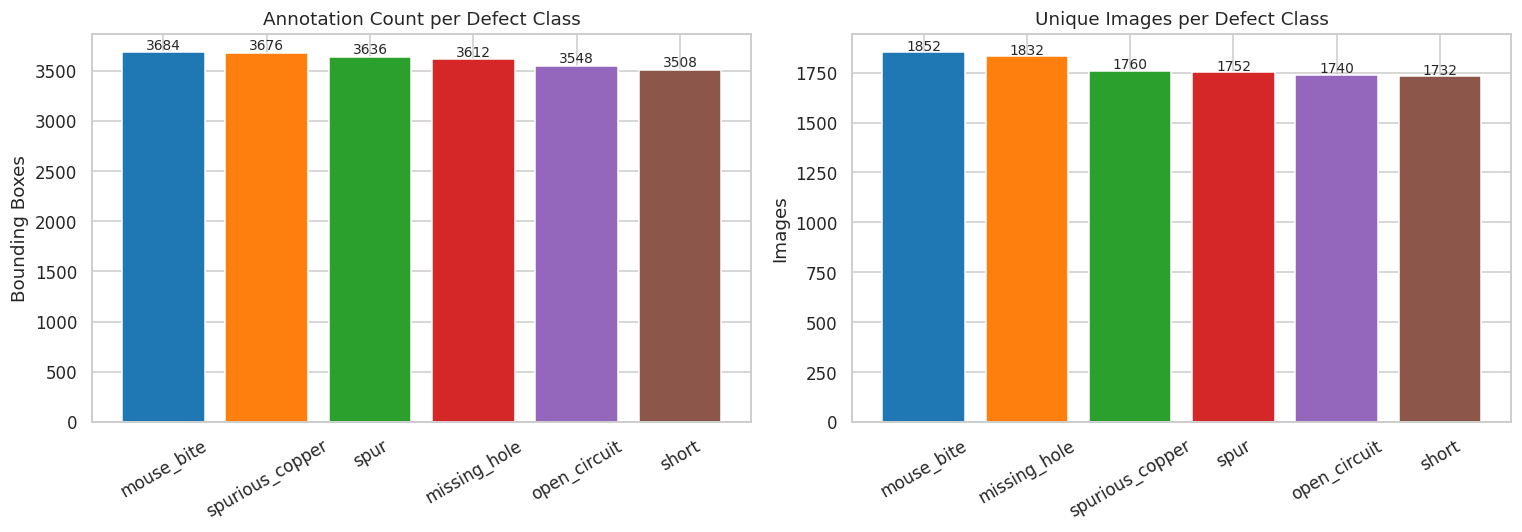

Imbalance ratio (max/min annotations): 1.05


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = cleaned_df.groupby('class_name').size().sort_values(ascending=False)
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('tab10', 6))
axes[0].set_title('Annotation Count per Defect Class')
axes[0].set_ylabel('Bounding Boxes')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

img_per_class = cleaned_df.groupby('class_name')['image_name'].nunique().sort_values(ascending=False)
axes[1].bar(img_per_class.index, img_per_class.values, color=sns.color_palette('tab10', 6))
axes[1].set_title('Unique Images per Defect Class')
axes[1].set_ylabel('Images')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(img_per_class.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print('Imbalance ratio (max/min annotations):', round(class_counts.max() / class_counts.min(), 2))

### 8b. Split Distribution per Class

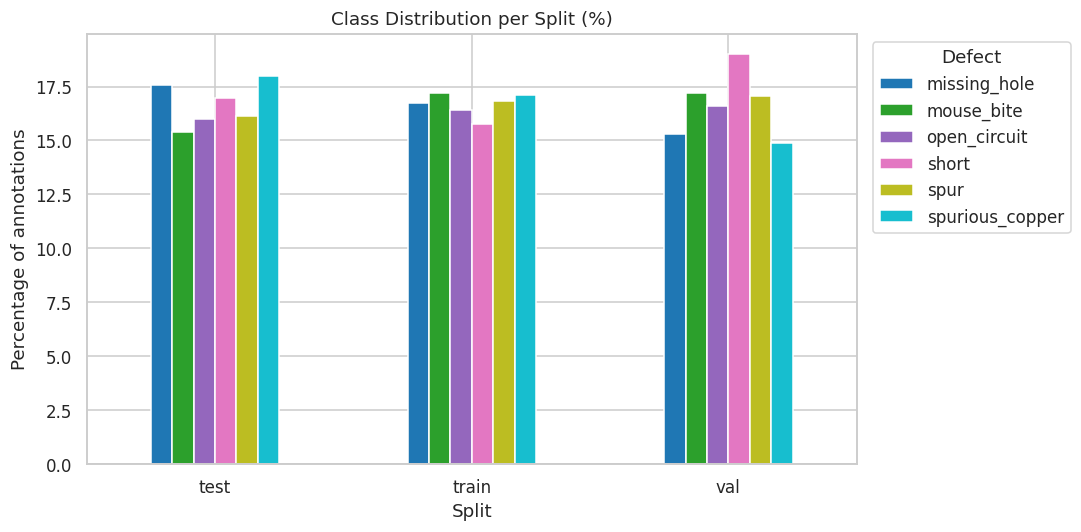


Annotation counts:
class_name  missing_hole  mouse_bite  open_circuit  short  spur  \
split                                                             
test                 379         332           345    366   348   
train               2902        2980          2844   2731  2919   
val                  331         372           359    411   369   

class_name  spurious_copper  
split                        
test                    388  
train                  2966  
val                     322  


In [18]:
split_class     = cleaned_df.groupby(['split', 'class_name']).size().unstack(fill_value=0)
split_class_pct = split_class.div(split_class.sum(axis=1), axis=0) * 100

split_class_pct.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
plt.title('Class Distribution per Split (%)')
plt.ylabel('Percentage of annotations')
plt.xlabel('Split')
plt.xticks(rotation=0)
plt.legend(title='Defect', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print('\nAnnotation counts:')
print(split_class)

### 8c. Augmentation Distribution

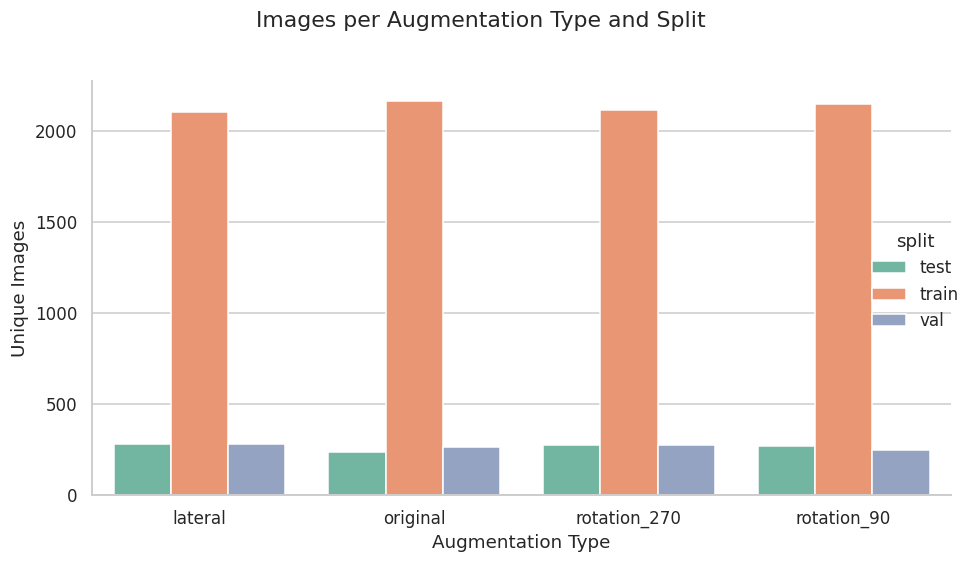

In [19]:
aug_counts = (
    cleaned_df.groupby(['split','augmentation'])['image_name']
    .nunique().reset_index(name='unique_images')
)
g = sns.catplot(data=aug_counts, x='augmentation', y='unique_images', hue='split',
                kind='bar', height=5, aspect=1.6, palette='Set2')
g.set_axis_labels('Augmentation Type', 'Unique Images')
g.fig.suptitle('Images per Augmentation Type and Split', y=1.02)
plt.tight_layout()
plt.show()

### 8d. BBox Size Distribution per Defect (KDE)

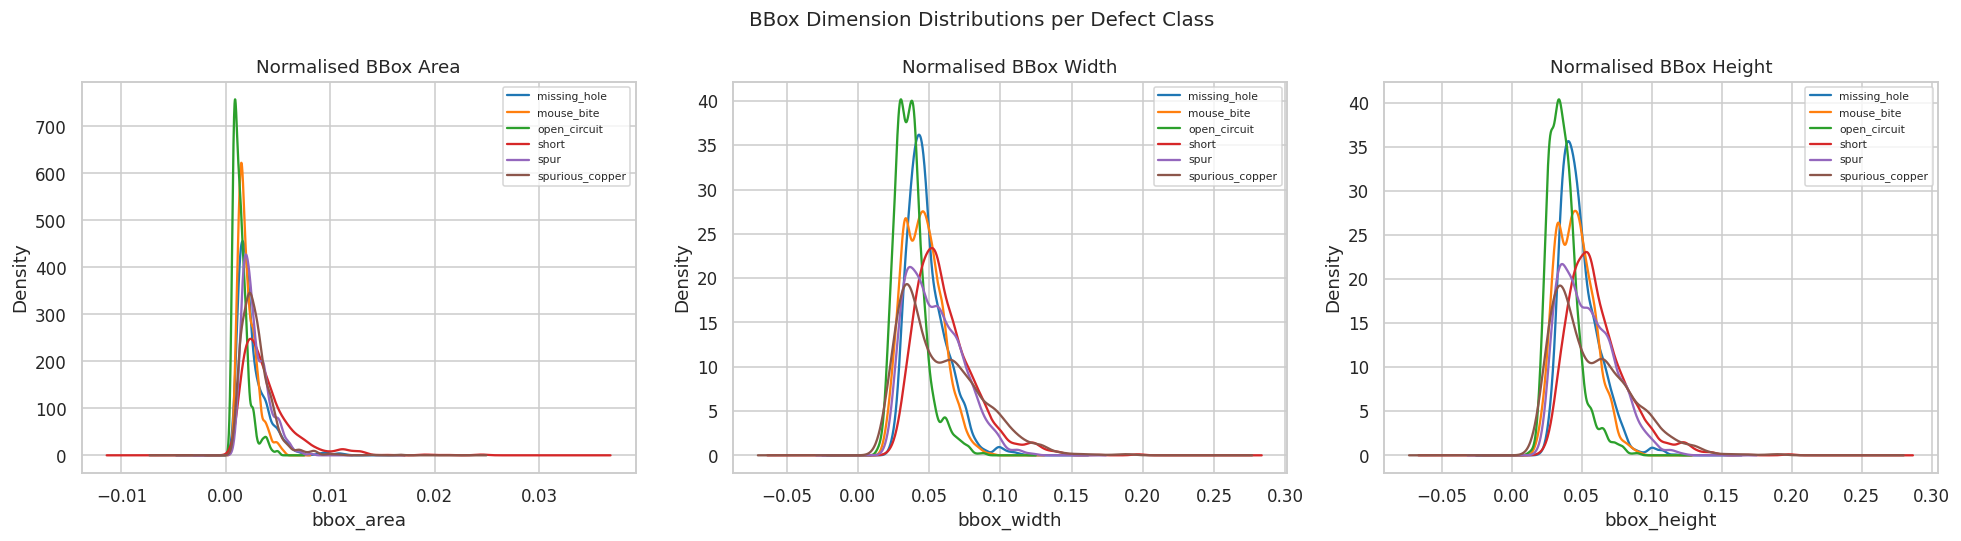

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['bbox_area', 'bbox_width', 'bbox_height']
titles   = ['Normalised BBox Area', 'Normalised BBox Width', 'Normalised BBox Height']

for ax, feat, title in zip(axes, features, titles):
    for cls in sorted(cleaned_df['class_name'].unique()):
        cleaned_df[cleaned_df['class_name'] == cls][feat].dropna().plot.kde(
            ax=ax, label=cls, linewidth=1.5
        )
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.legend(fontsize=7)

plt.suptitle('BBox Dimension Distributions per Defect Class', fontsize=13)
plt.tight_layout()
plt.show()

### 8e. Spatial Heatmap — Where do defects appear on the PCB?

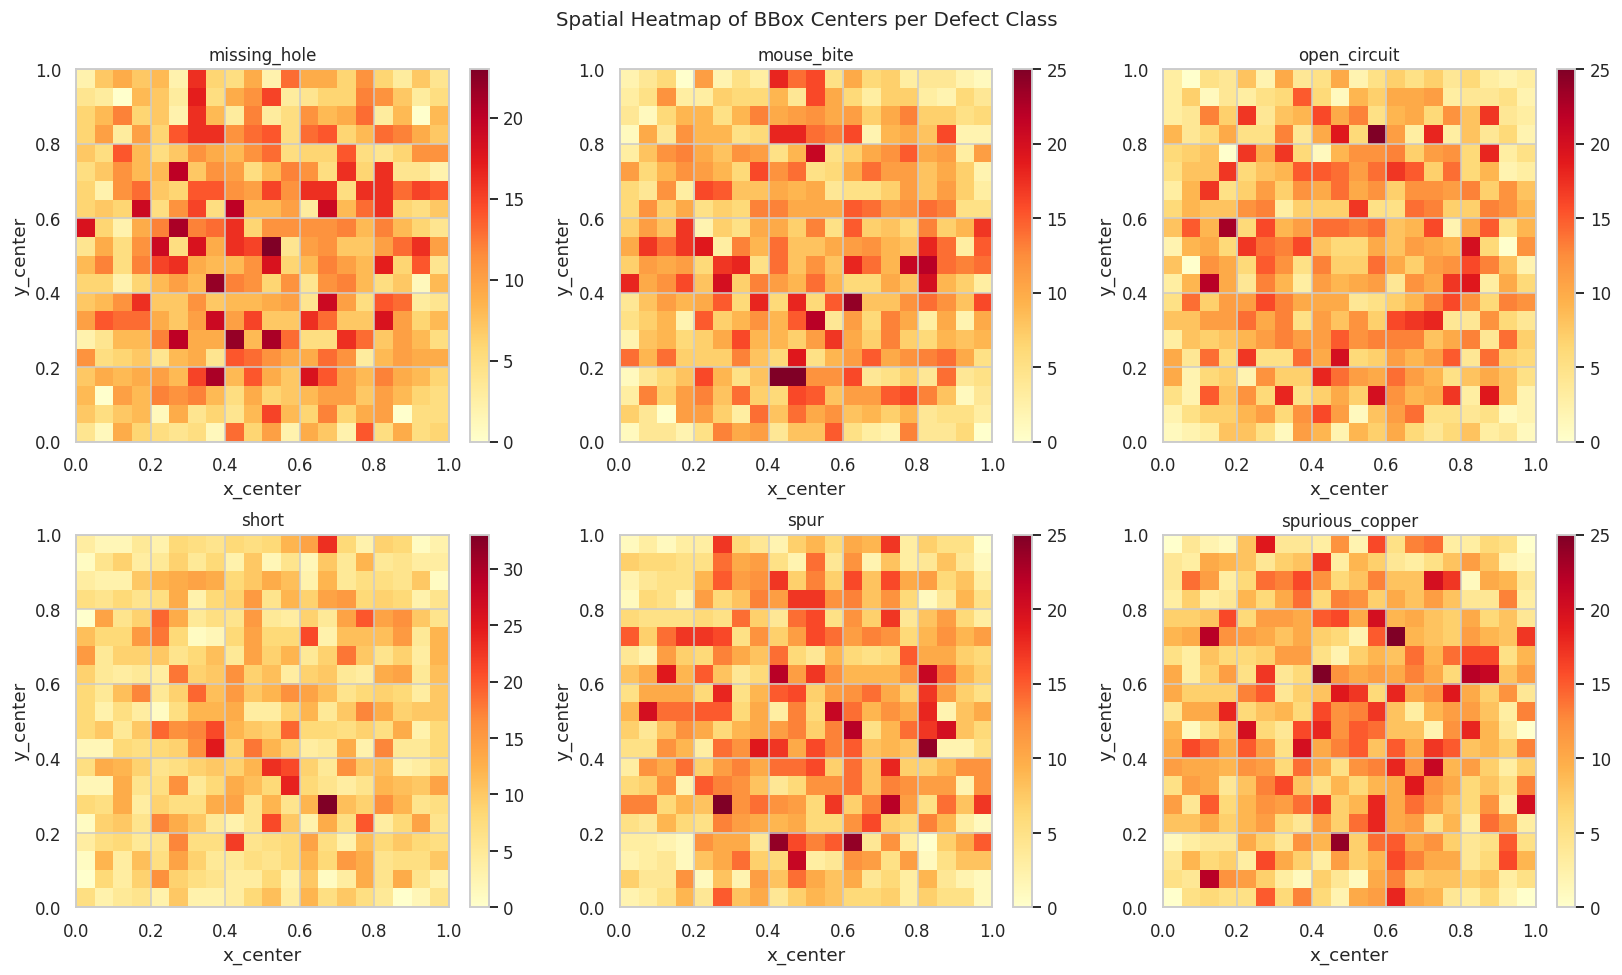

In [21]:
classes = sorted(cleaned_df['class_name'].unique())
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, cls in zip(axes.flat, classes):
    subset = cleaned_df[cleaned_df['class_name'] == cls]
    h, _, _ = np.histogram2d(
        subset['x_center'], subset['y_center'], bins=20, range=[[0,1],[0,1]]
    )
    im = ax.imshow(h.T, origin='lower', extent=[0,1,0,1], cmap='YlOrRd', aspect='equal')
    ax.set_title(cls, fontsize=11)
    ax.set_xlabel('x_center')
    ax.set_ylabel('y_center')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Spatial Heatmap of BBox Centers per Defect Class', fontsize=13)
plt.tight_layout()
plt.show()

### 8f. Defects per Image Histogram

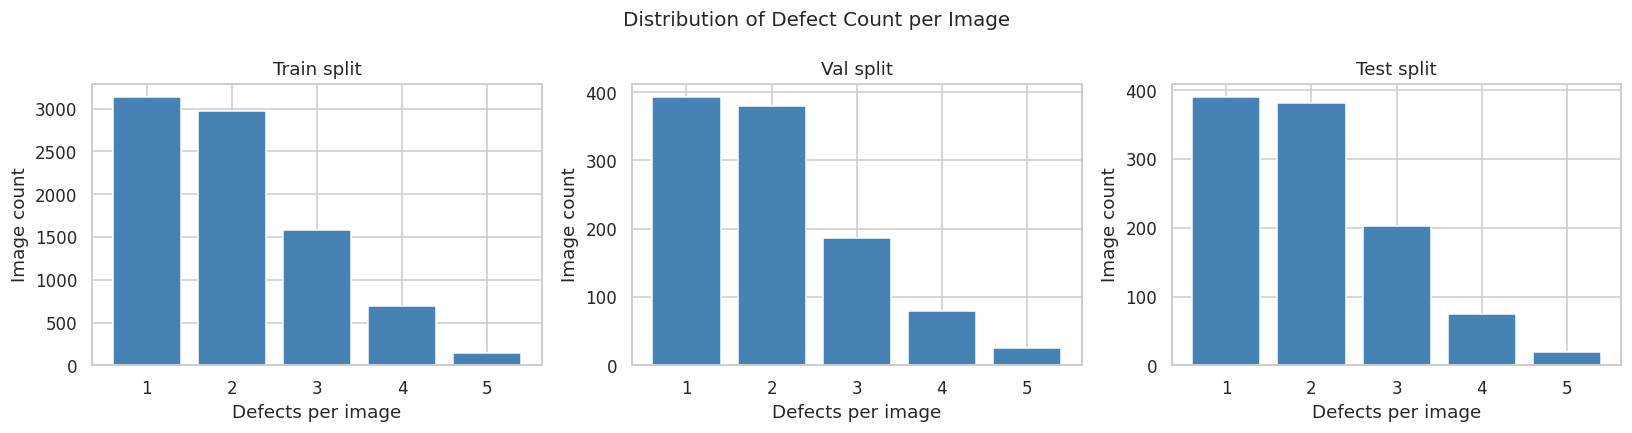

In [22]:
defects_per_img = cleaned_df.groupby(['image_name', 'split']).size().reset_index(name='defect_count')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, SPLITS):
    data = defects_per_img[defects_per_img['split'] == split]['defect_count']
    cnt  = Counter(data)
    ax.bar(cnt.keys(), cnt.values(), color='steelblue', edgecolor='white')
    ax.set_title(f'{split.capitalize()} split')
    ax.set_xlabel('Defects per image')
    ax.set_ylabel('Image count')
    ax.set_xticks(sorted(cnt.keys()))

plt.suptitle('Distribution of Defect Count per Image', fontsize=13)
plt.tight_layout()
plt.show()

### 8g. Co-occurrence Matrix — Which defects appear together?

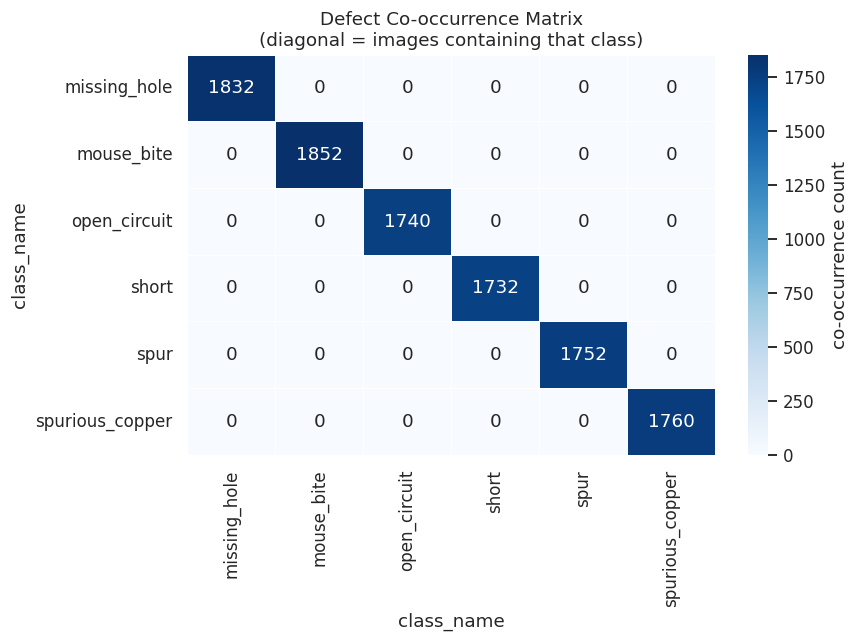

In [23]:
presence = cleaned_df.groupby(['image_name', 'class_name']).size().unstack(fill_value=0).clip(upper=1)
cooccur  = presence.T.dot(presence)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooccur, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'co-occurrence count'}, ax=ax)
ax.set_title('Defect Co-occurrence Matrix\n(diagonal = images containing that class)')
plt.tight_layout()
plt.show()

### 8h. Aspect Ratio per Class (Violin)

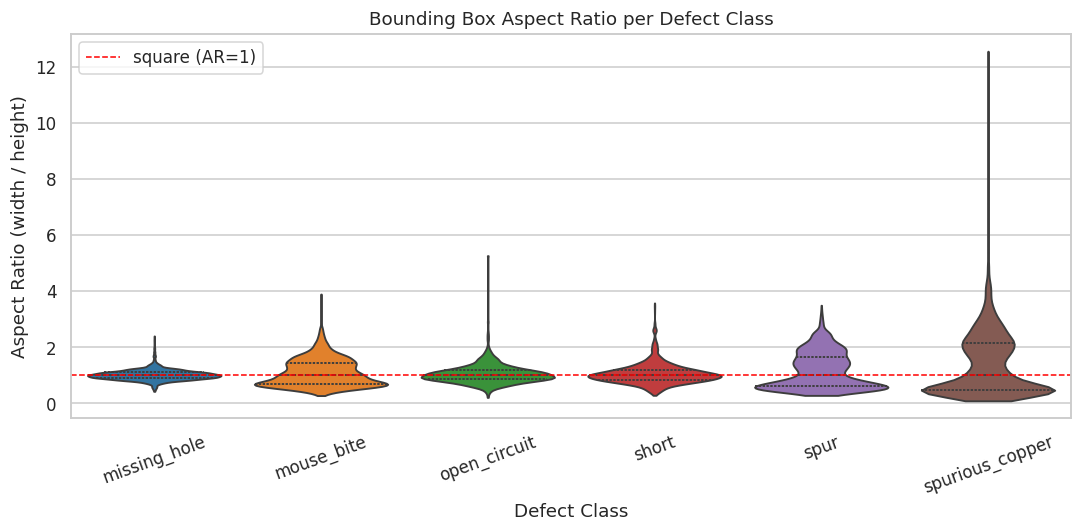

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(cleaned_df['class_name'].unique())
sns.violinplot(data=cleaned_df, x='class_name', y='aspect_ratio',
               order=order, palette='tab10', inner='quartile', cut=0, ax=ax)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='square (AR=1)')
ax.set_title('Bounding Box Aspect Ratio per Defect Class')
ax.set_xlabel('Defect Class')
ax.set_ylabel('Aspect Ratio (width / height)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

### 8i. Sample Images with Bounding Box Overlays

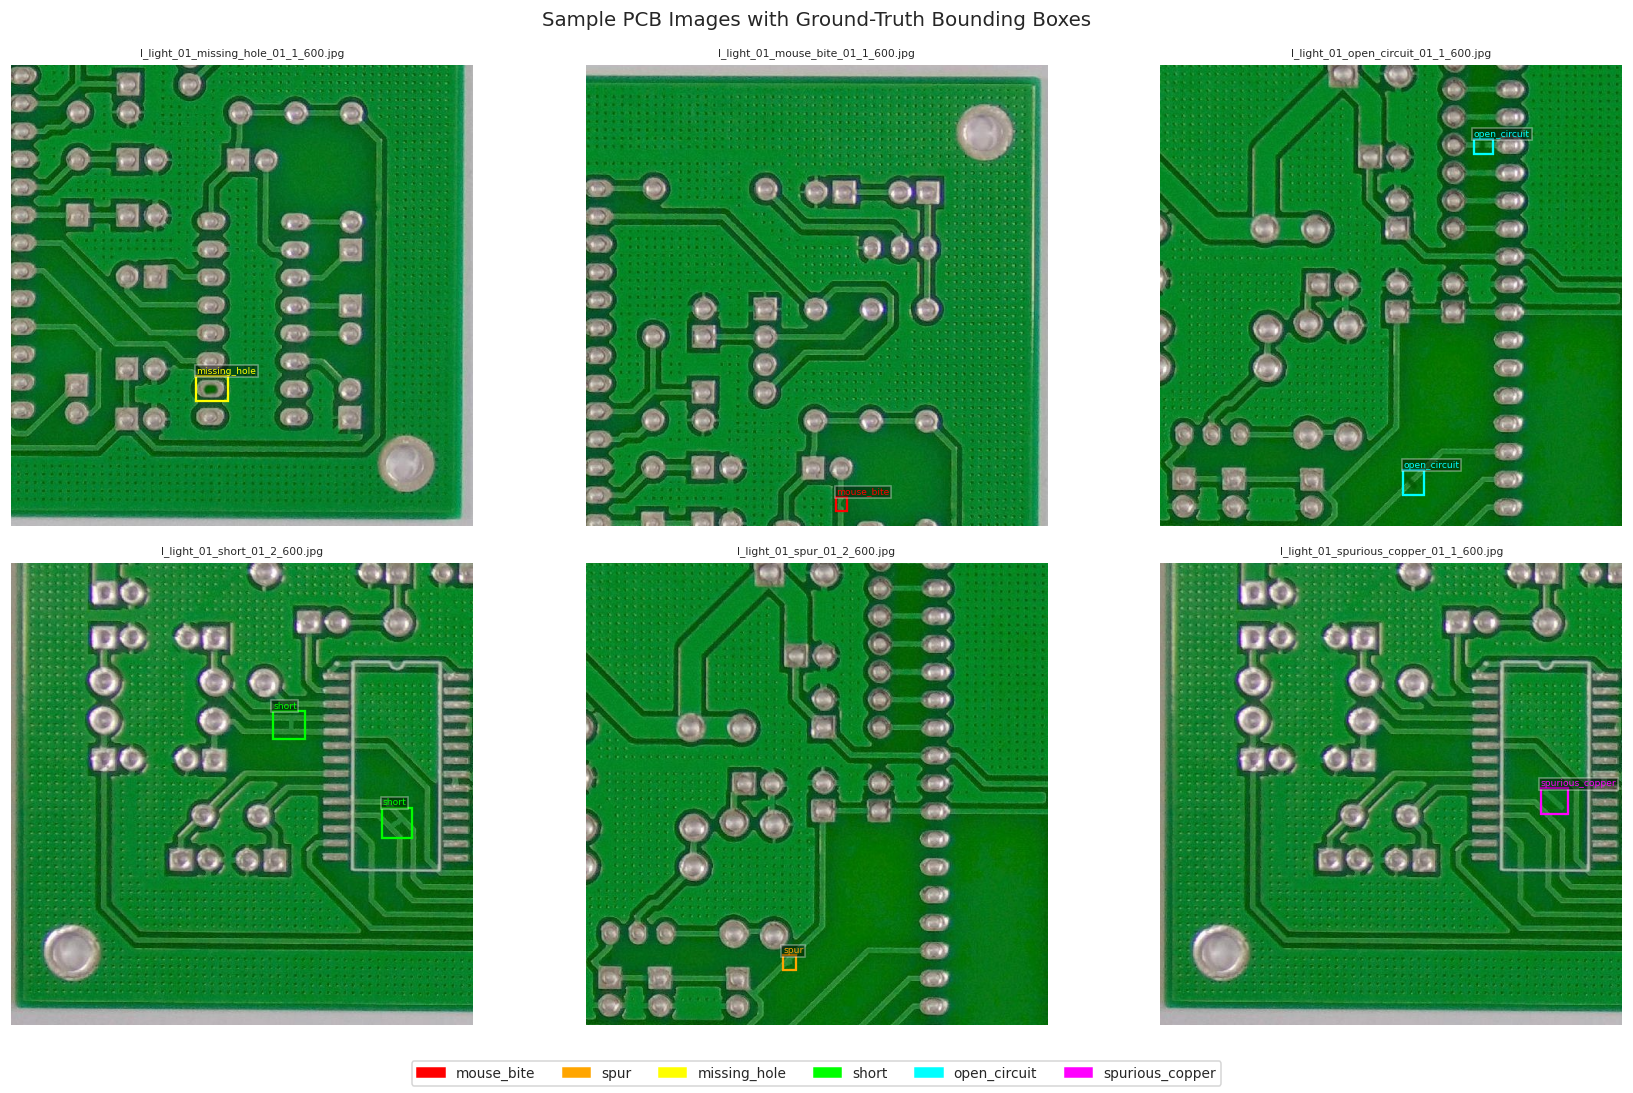

In [25]:
CLASS_COLORS = {
    'mouse_bite':      'red',
    'spur':            'orange',
    'missing_hole':    'yellow',
    'short':           'lime',
    'open_circuit':    'cyan',
    'spurious_copper': 'magenta',
}

def draw_bboxes(image_name, split, ax):
    img_path = DATA_ROOT / split / 'images' / image_name
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    rows = cleaned_df[cleaned_df['image_name'] == image_name]
    for _, row in rows.iterrows():
        xc, yc, bw, bh = row['x_center'], row['y_center'], row['bbox_width'], row['bbox_height']
        x0 = (xc - bw / 2) * W
        y0 = (yc - bh / 2) * H
        color = CLASS_COLORS.get(row['class_name'], 'white')
        rect  = mpatches.Rectangle((x0, y0), bw * W, bh * H,
                                    linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x0, y0 - 3, row['class_name'], color=color, fontsize=6,
                bbox=dict(facecolor='black', alpha=0.4, pad=1))
    ax.axis('off')
    ax.set_title(image_name[:40], fontsize=7)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, cls in zip(axes.flat, sorted(CLASS_COLORS.keys())):
    sample = cleaned_df[cleaned_df['class_name'] == cls].iloc[0]
    draw_bboxes(sample['image_name'], sample['split'], ax)

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in CLASS_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=6, fontsize=9, frameon=True)
plt.suptitle('Sample PCB Images with Ground-Truth Bounding Boxes', fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 9. Data Leakage Audit

In [26]:
split_img_sets = {s: set(cleaned_df[cleaned_df['split'] == s]['image_name']) for s in SPLITS}

print('=' * 60)
print('DATA LEAKAGE AUDIT')
print('=' * 60)

# Exact image overlap
for a, b in [('train','val'), ('train','test'), ('val','test')]:
    overlap = split_img_sets[a] & split_img_sets[b]
    status  = 'CLEAN' if not overlap else f'LEAK — {len(overlap)} shared images'
    print(f'  Exact image overlap {a}/{b}: {status}')

# Scene-level (augmentation) leakage
def base_id(filename):
    name = filename.replace('.jpg', '')
    return re.sub(r'^(rotation_\d+_|l_)', '', name)

cleaned_df['base_id'] = cleaned_df['image_name'].apply(base_id)
base_splits   = cleaned_df.groupby('base_id')['split'].nunique()
cross_scene   = base_splits[base_splits > 1]
n_cross = len(cross_scene)
print(f'  Base-scene spanning splits: {n_cross}',
      '(RISK — augmentations of same PCB scan span train/val/test)' if n_cross > 0 else '(CLEAN)')

print('  class_name in features: NO — it is the label, not an input feature')
print('=' * 60)

DATA LEAKAGE AUDIT
  Exact image overlap train/val: CLEAN
  Exact image overlap train/test: CLEAN
  Exact image overlap val/test: CLEAN
  Base-scene spanning splits: 1556 (RISK — augmentations of same PCB scan span train/val/test)
  class_name in features: NO — it is the label, not an input feature


## 10. Final Summary

In [27]:
print('=' * 60)
print('CLEANEDDATASET.CSV — FINAL SUMMARY')
print('=' * 60)
print(f'Total bounding box annotations : {len(cleaned_df):,}')
print(f'Total unique images            : {cleaned_df["image_name"].nunique():,}')
print()
for split in SPLITS:
    s = cleaned_df[cleaned_df['split'] == split]
    print(f'  {split:5s} | images: {s["image_name"].nunique():5,} | annotations: {len(s):6,}')
print()
print('Class distribution (total annotations):')
print(cleaned_df['class_name'].value_counts().to_string())
print()
print(f'Null values          : {cleaned_df.isnull().any(axis=1).sum()}')
print(f'Duplicate rows       : {cleaned_df.duplicated().sum()}')
print(f'BBox area outliers   : {cleaned_df["is_outlier_area"].sum()} (flagged, kept)')
print(f'Aspect ratio outliers: {cleaned_df["is_outlier_ar"].sum()} (flagged, kept)')
print(f'Output file          : {out_path}')

CLEANEDDATASET.CSV — FINAL SUMMARY
Total bounding box annotations : 21,664
Total unique images            : 10,668

  train | images: 8,534 | annotations: 17,342
  val   | images: 1,066 | annotations:  2,164
  test  | images: 1,068 | annotations:  2,158

Class distribution (total annotations):
class_name
mouse_bite         3684
spurious_copper    3676
spur               3636
missing_hole       3612
open_circuit       3548
short              3508

Null values          : 0
Duplicate rows       : 0
BBox area outliers   : 430 (flagged, kept)
Aspect ratio outliers: 432 (flagged, kept)
Output file          : /home/codrei/my_first_ml_project/DATA MINING/FINALS/pcb-defect-mining/data/processed/CleanedDataset.csv
